## Risk Analyst - FX & Liquidity Management

**Scenario:**  
Ein deutsches Unternehmen muss in 3 Monaten 10 Millionen USD bezahlen. Wie viele Euros wird es vermutlich dafür zurück legen müssen?

In [2]:
usd_exposure = 10_000_000

exchange_rates = [0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]

for eur_usd in exchange_rates:
    eur_value = usd_exposure / eur_usd
    print(f"EUR/USD: {eur_usd:.2f} -> EUR exposure: {eur_value:,.2f} Euro")

EUR/USD: 0.95 -> EUR exposure: 10,526,315.79 Euro
EUR/USD: 1.00 -> EUR exposure: 10,000,000.00 Euro
EUR/USD: 1.05 -> EUR exposure: 9,523,809.52 Euro
EUR/USD: 1.10 -> EUR exposure: 9,090,909.09 Euro
EUR/USD: 1.15 -> EUR exposure: 8,695,652.17 Euro
EUR/USD: 1.20 -> EUR exposure: 8,333,333.33 Euro
EUR/USD: 1.25 -> EUR exposure: 8,000,000.00 Euro


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://data-api.ecb.europa.eu/service/data/EXR/D.USD.EUR.SP00.A?startPeriod=2024-09-01&endPeriod=2026-09-21&format=csvdata"

df = pd.read_csv(url)

fx = df[['TIME_PERIOD', 'OBS_VALUE']].copy()
fx['DATE'] = pd.to_datetime(fx['TIME_PERIOD'])
fx["EURUSD"] = pd.to_numeric(fx['OBS_VALUE'], errors='coerce')
fx = fx.sort_values(by='DATE')
fx = fx.reset_index(drop=True)
fx = fx[['DATE', 'EURUSD']].copy()
fx.head()

,DATE,EURUSD
0,2024-09-02,1.1061
1,2024-09-03,1.1035
2,2024-09-04,1.1050
3,2024-09-05,1.1097
4,2024-09-06,1.1103


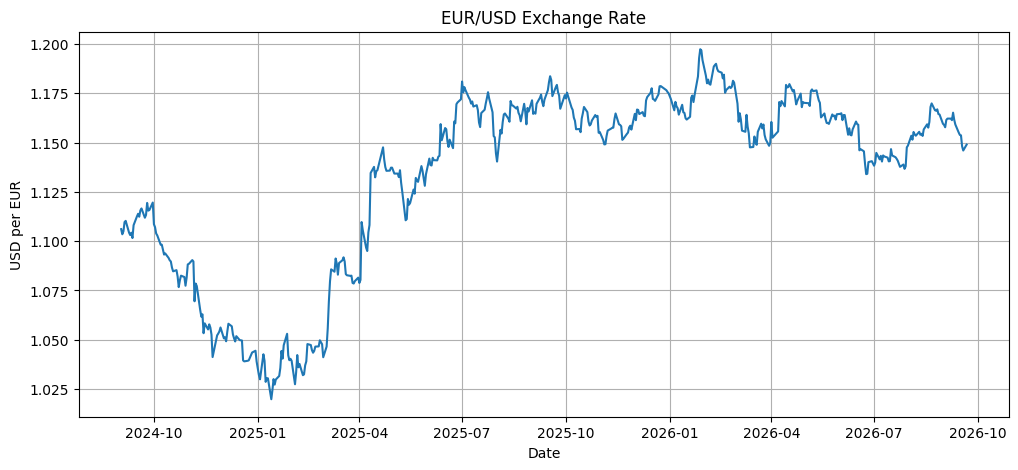

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(fx["DATE"], fx["EURUSD"])

plt.title("EUR/USD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD per EUR")
plt.grid(True)

plt.show()

In [8]:
fx["returns"] = fx["EURUSD"].pct_change()   # tägliche Renditen berechnen (Prozentuale Veränderung)

daily_vol = fx["returns"].std()  # tägliche Volatilität berechnen (Standardabweichung der Renditen)
annual_vol = daily_vol * (252 ** 0.5)  # jährliche Volatilität berechnen (252: Anzahl der Handelstage im Jahr)

print(f"Tägliche Volatilität: {daily_vol:.4%}")
print(f"Jährliche Volatilität: {annual_vol:.4%}")

Tägliche Volatilität: 0.4429%
Jährliche Volatilität: 7.0304%


In [13]:
# 1sigma Wechselkursschock Besipiel

spot = 1.10
forward_rate = 1.10
usd_exposure = 10_000_000
scenarios = [0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]

one_sigma_up = spot * (1 + annual_vol)
one_sigma_down = spot * (1 - annual_vol)

print(f"1-Sigma Up: {one_sigma_up:.4f}")
print(f"1-Sigma Down: {one_sigma_down:.4f}")

# Euro kosten bei 1-Sigma Up und Down
base_cost = usd_exposure / spot
up_cost = usd_exposure / one_sigma_up
down_cost = usd_exposure / one_sigma_down

print(f"Base cost:     €{base_cost:,.0f}")
print(f"Cost at 1σ up: €{up_cost:,.0f}")
print(f"Cost at 1σ down: €{down_cost:,.0f}")
print(" ")

unhedged_c = []
hedged_c = []

for spot_rate in scenarios:
    unhedged_cost = usd_exposure / spot_rate
    hedged_cost = usd_exposure / forward_rate
    print(f"Spot rate: {spot_rate:.2f} -> Unhedged cost: €{unhedged_cost:,.0f}, Hedged cost: €{hedged_cost:,.0f}") 
    unhedged_c.append(unhedged_cost)
    hedged_c.append(hedged_cost)


1-Sigma Up: 1.1773
1-Sigma Down: 1.0227
Base cost:     €9,090,909
Cost at 1σ up: €8,493,760
Cost at 1σ down: €9,778,372
 
Spot rate: 0.95 -> Unhedged cost: €10,526,316, Hedged cost: €9,090,909
Spot rate: 1.00 -> Unhedged cost: €10,000,000, Hedged cost: €9,090,909
Spot rate: 1.05 -> Unhedged cost: €9,523,810, Hedged cost: €9,090,909
Spot rate: 1.10 -> Unhedged cost: €9,090,909, Hedged cost: €9,090,909
Spot rate: 1.15 -> Unhedged cost: €8,695,652, Hedged cost: €9,090,909
Spot rate: 1.20 -> Unhedged cost: €8,333,333, Hedged cost: €9,090,909
Spot rate: 1.25 -> Unhedged cost: €8,000,000, Hedged cost: €9,090,909


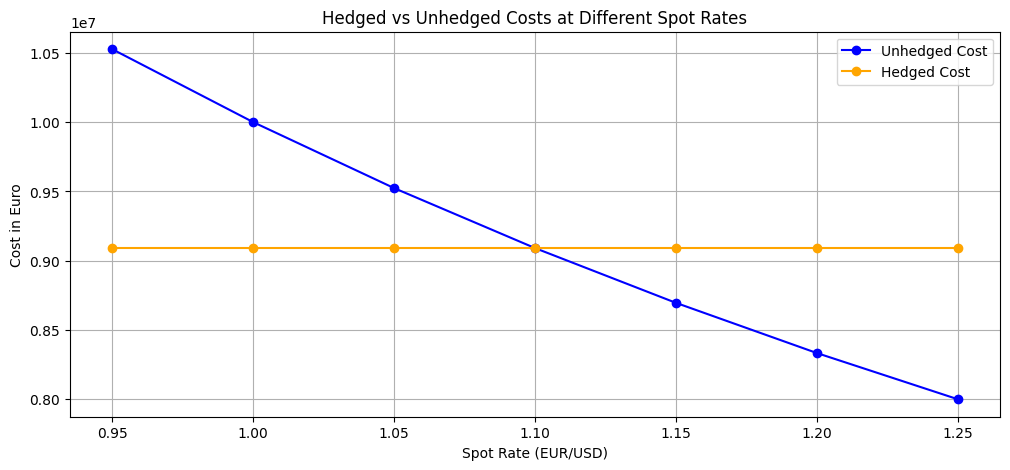

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(scenarios, unhedged_c, color='blue', label='Unhedged Cost', marker='o')
plt.plot(scenarios, hedged_c, color='orange', label='Hedged Cost', marker='o')
plt.title("Hedged vs Unhedged Costs at Different Spot Rates")
plt.xlabel("Spot Rate (EUR/USD)")
plt.ylabel("Cost in Euro")
plt.legend()
plt.grid(True)
plt.show()

#### Hedging bedeutet nicht, den günstigsten möglichen Wechselkurs zu bekommen. Es bedeutet, die Unsicherheit über zukünftige Cashflows zu reduzieren.

In [23]:
# Realistischer FX Forward

spot = 1.10
r_eur = 0.025   # 2.5% annual interest rate for EUR
r_usd = 0.045   # 4.5% annual interest rate for USD
T = 3/12  # 3 months in years
annual_vol = 0.070304

forward_rate = spot * (1 + r_eur * T) / (1 + r_usd * T)
print(f"Forward Rate: {forward_rate:.4f}")

usd_exposure = 100000  
hedged_cost = usd_exposure / forward_rate
print(f"Hedged cost with realistic forward: €{hedged_cost:,.0f}")

vol_3m = annual_vol * (T ** 0.5)
print(f"3-Month Volatility: {vol_3m:.4%}")

up = spot * (1 + vol_3m)
down = spot * (1 - vol_3m)
spot_cost_up = usd_exposure / up
spot_cost_down = usd_exposure / down

print(f"Spot cost at 1σ up: €{spot_cost_up:,.0f}")
print(f"Spot cost at 1σ down: €{spot_cost_down:,.0f}")
print(" ")

for name, fx_rate in [("Spot", spot), ("Forward", forward_rate), ("1σ Up", up), ("1σ Down", down)]:
    unhedged_cost = usd_exposure / fx_rate
    hedged_cost = usd_exposure / forward_rate
    print(f"{name} rate: {fx_rate:.4f} -> Unhedged: €{unhedged_cost:,.0f}, Hedged: €{hedged_cost:,.0f}")

Forward Rate: 1.0946
Hedged cost with realistic forward: €91,361
3-Month Volatility: 3.5152%
Spot cost at 1σ up: €87,822
Spot cost at 1σ down: €94,221
 
Spot rate: 1.1000 -> Unhedged: €90,909, Hedged: €91,361
Forward rate: 1.0946 -> Unhedged: €91,361, Hedged: €91,361
1σ Up rate: 1.1387 -> Unhedged: €87,822, Hedged: €91,361
1σ Down rate: 1.0613 -> Unhedged: €94,221, Hedged: €91,361


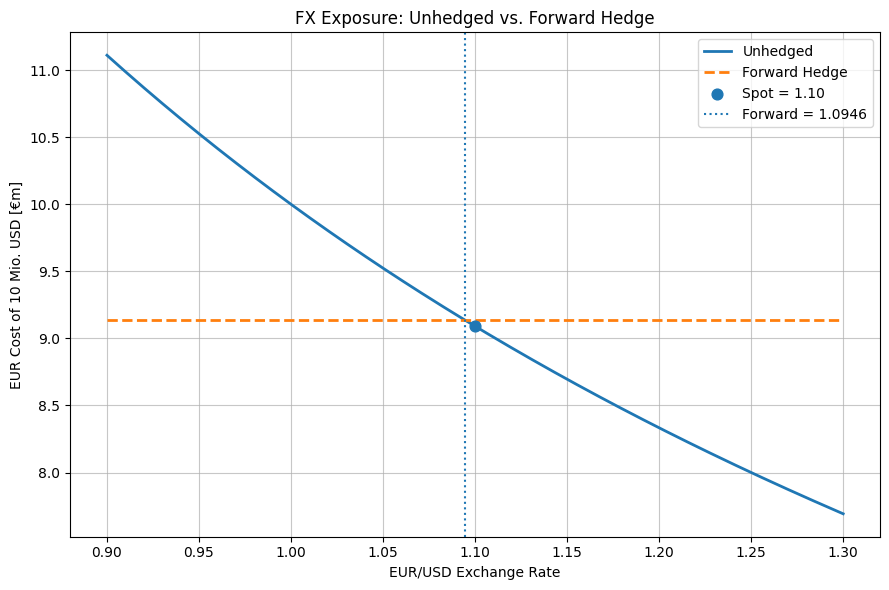

Unhedged Volatility: 985,695.34 Euro
Hedged Volatility: 0.00 Euro
Risk Reduction: 100.00%


In [32]:
# Range of possible EUR/USD exchange rates
fx_rates = np.linspace(0.90, 1.30, 200)

unhedged_cost = usd_exposure / fx_rates

hedged_cost = np.full_like(fx_rates, usd_exposure / forward_rate)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(fx_rates, unhedged_cost / 1e6, label="Unhedged", linewidth=2)

ax.plot(fx_rates, hedged_cost / 1e6, label="Forward Hedge", linewidth=2, linestyle="--")

spot = 1.10
spot_cost = usd_exposure / spot

ax.scatter( spot, spot_cost / 1e6, s=60, zorder=3, label="Spot = 1.10")

ax.axvline(forward_rate, linestyle=":", linewidth=1.5, label=f"Forward = {forward_rate:.4f}")
ax.set_title("FX Exposure: Unhedged vs. Forward Hedge")
ax.set_xlabel("EUR/USD Exchange Rate")
ax.set_ylabel("EUR Cost of 10 Mio. USD [€m]")
ax.grid(True, alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

# Risk Analysis DataFrame
risk_analysis = pd.DataFrame({
    "EURUSD": fx_rates,
    "Unhedged_EUR": unhedged_cost,
    "Hedged_EUR": hedged_cost
})
#print(risk_analysis.head())

# Schwankungsbreite
unhedged_vol = risk_analysis["Unhedged_EUR"].std()
hedged_vol = risk_analysis["Hedged_EUR"].std()
print(f"Unhedged Volatility: {unhedged_vol:,.2f} Euro")
print(f"Hedged Volatility: {hedged_vol:,.2f} Euro")

# Risk Reduction
risk_reduction = (unhedged_vol - hedged_vol) / unhedged_vol
print(f"Risk Reduction: {risk_reduction:.2%}")

Mean simulated FX rate: 1.0999
Minimum FX rate: 0.9577, Maximum FX rate: 1.2620

Mean Unhedged Cost: €9,102,871
STD Unhedged Cost: €321,168

Forward hedged Cost: €9,135,757


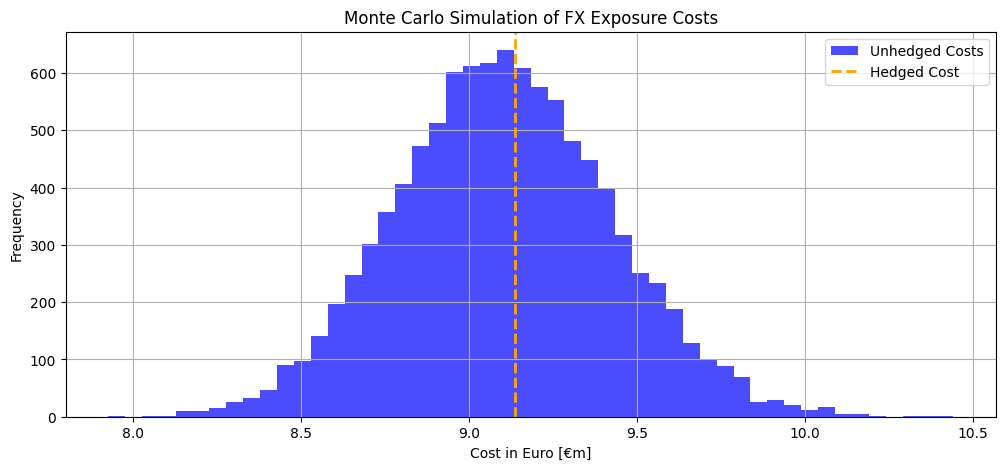

In [33]:
# Monte Carlo Simulation for FX Exposure
np.random.seed(42)  

usd_exposure = 10_000_000
spot = 1.10
forward_rate = 1.0946
annual_vol = 0.070304
T = 3/12  # 3 months in years
n_simulations = 10000

# random standard normal variables
z = np.random.standard_normal(n_simulations)

simulated_fx = spot*np.exp(-0.5*annual_vol**2*T + annual_vol*np.sqrt(T)*z)

unhedged_costs = usd_exposure / simulated_fx
hedged_costs = np.full_like(unhedged_costs, usd_exposure / forward_rate)

print(f"Mean simulated FX rate: {simulated_fx.mean():.4f}")
print(f"Minimum FX rate: {simulated_fx.min():.4f}, Maximum FX rate: {simulated_fx.max():.4f}")
print()

print(f"Mean Unhedged Cost: €{unhedged_costs.mean():,.0f}")
print(f"STD Unhedged Cost: €{unhedged_costs.std():,.0f}")
print()

print(f"Forward hedged Cost: €{hedged_costs[0]:,.0f}")


plt.figure(figsize=(12, 5))
plt.hist(unhedged_costs / 1e6, bins=50, alpha=0.7, label='Unhedged Costs', color='blue')
plt.axvline(hedged_costs[0] / 1e6, color='orange', linestyle='dashed', linewidth=2, label='Hedged Cost')
plt.title("Monte Carlo Simulation of FX Exposure Costs")
plt.xlabel("Cost in Euro [€m]")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()  

In [41]:
# 95 Value at Risk
var_95 = np.percentile(unhedged_costs, 95)
print(f"95% Value at Risk (VaR): €{var_95:,.0f}")

# 95% Expected Shortfall (Conditional VaR)
tail_losses = unhedged_cost[unhedged_cost >= var_95]
es_95 = unhedged_costs[unhedged_costs >= var_95].mean()
print(f"95% Expected Shortfall (ES): €{es_95:,.0f}")

forward_cost = usd_exposure / forward_rate
print(f"Forward hedged Cost: €{forward_cost:,.0f}")

var_vs_forward = var_95 - forward_cost
es_vs_forward = es_95 - forward_cost
print(f"VaR vs Forward Cost: €{var_vs_forward:,.0f}")
print(f"ES vs Forward Cost: €{es_vs_forward:,.0f}")

95% Value at Risk (VaR): €9,641,381
95% Expected Shortfall (ES): €9,785,824
Forward hedged Cost: €9,135,757
VaR vs Forward Cost: €505,623
ES vs Forward Cost: €650,067


In [42]:
print("VaR:", var_95)
print("ES:", es_95)

print("\nTail statistics:")
print("Min:", tail_losses.min())
print("Max:", tail_losses.max())
print("Mean:", tail_losses.mean())
print("Number of tail observations:", len(tail_losses))

VaR: 9641380.661771627
ES: 9785824.087754078

Tail statistics:
Min: 9646146.388754241
Max: 11111111.11111111
Mean: 10344637.904123837
Number of tail observations: 69
